# Question 1 — borough clustering and temporal stability

This notebook asks whether boroughs form reproducible multivariate groups beyond the official Inner/Outer split. It is deliberately separate from descriptive analysis because clustering is exploratory and requires its own choices about features, scaling, dimension reduction, cluster count and stability.

The workflow compares K-means and Ward clustering for 2–8 groups, rejects clusters with fewer than four boroughs, uses PCA to retain at least 90% of variance, and evaluates stability with 500 year-block bootstraps. Four independent two-year windows then test whether the borough structure persists or changes. Figures are displayed only; no files are saved.

## 1. Load the borough-year panel and map

Only annual borough rows are needed. Years 1–6 define the primary clustering solution; Years 7–8 are held back for temporal validation rather than helping choose the solution.

In [1]:
# Load clustering libraries, annual borough data and the 32-borough boundary file.
from pathlib import Path
import os
import warnings

# Set this before third-party imports so joblib has a portable Windows fallback.
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count() or 1))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 2026

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
ANNUAL_PATH = PROJECT_ROOT / 'question1_outputs' / 'prepared_data' / 'q1_annual.csv'
BOUNDARY_PATH = PROJECT_ROOT / 'extradata' / 'london_borough_boundaries.geojson'
assert ANNUAL_PATH.exists() and BOUNDARY_PATH.exists()

annual = pd.read_csv(ANNUAL_PATH)
borough_annual = annual.loc[annual['geography_level'].eq('Borough')].copy()
borough_boundaries = gpd.read_file(BOUNDARY_PATH)[['gss_code', 'name', 'geometry']]
assert len(borough_annual) == 32 * 8 and borough_annual['geography_code'].nunique() == 32

## 2. Select a primary borough solution

The feature set avoids mechanically duplicated variables: one activity level, two dynamic activity measures, limiting disability, population ageing, relative earnings, migration and the stated selected-crime context. Features are standardised before PCA so different units do not determine distance.

In [2]:
cluster_panel = borough_annual.loc[borough_annual['year'].between(1, 6)].copy()


def build_cluster_profile(frame):
    means = frame.groupby(['geography_code', 'geography_name', 'inner_outer'], as_index=False).agg(
        active_level=('active_rate', 'mean'),
        limiting_disability=('limiting_disability_rate', 'mean'),
        population_age_65_plus=('population_age_65_plus_rate', 'mean'),
        relative_earnings=('earnings_relative_to_london', 'mean'),
        net_migration=('net_migration_per_1000', 'mean'),
        selected_crime=('selected_recorded_crime_rate_per_1000', 'mean'),
    )
    dynamics = []
    for geography_code, group in frame.groupby('geography_code'):
        x = group['year'].to_numpy(dtype=float)
        y = group['active_rate'].to_numpy(dtype=float) * 100
        slope = np.polyfit(x, y, 1)[0] if np.unique(x).size > 1 else 0.0
        dynamics.append({
            'geography_code': geography_code,
            'active_trend_pp_per_year': slope,
            'active_volatility_pp': np.std(y, ddof=0),
        })
    return means.merge(pd.DataFrame(dynamics), on='geography_code', validate='one_to_one')


profile = build_cluster_profile(cluster_panel)
cluster_features = [
    'active_level', 'active_trend_pp_per_year', 'active_volatility_pp',
    'limiting_disability', 'population_age_65_plus', 'relative_earnings',
    'net_migration', 'selected_crime',
]
cluster_feature_labels = {
    'active_level': 'Active level',
    'active_trend_pp_per_year': 'Active trend',
    'active_volatility_pp': 'Active volatility',
    'limiting_disability': 'Limiting disability',
    'population_age_65_plus': 'Population age 65+',
    'relative_earnings': 'Relative earnings',
    'net_migration': 'Net migration',
    'selected_crime': 'Selected crime (context; specification-sensitive)',
}
feature_correlations = profile[cluster_features].corr()

scaler = StandardScaler()
scaled_profile = scaler.fit_transform(profile[cluster_features])
pca = PCA(n_components=.90, random_state=RANDOM_STATE)
profile_scores = pca.fit_transform(scaled_profile)


def fit_labels(method, k, values, seed=RANDOM_STATE):
    if method == 'K-means':
        return KMeans(n_clusters=k, n_init=30, random_state=seed).fit_predict(values)
    return AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(values)


bootstrap_geographies = profile['geography_code'].tolist()
bootstrap_years = np.arange(1, 7)
active_by_year = cluster_panel.pivot(
    index='geography_code', columns='year', values='active_rate'
).reindex(index=bootstrap_geographies, columns=bootstrap_years).to_numpy()
context_profile_features = [
    'limiting_disability_rate', 'population_age_65_plus_rate',
    'earnings_relative_to_london', 'net_migration_per_1000',
    'selected_recorded_crime_rate_per_1000',
]
context_by_year = np.stack([
    cluster_panel.pivot(index='geography_code', columns='year', values=feature)
    .reindex(index=bootstrap_geographies, columns=bootstrap_years).to_numpy()
    for feature in context_profile_features
], axis=2)


def resampled_cluster_matrix(sampled_years):
    positions = np.asarray(sampled_years) - 1
    active = active_by_year[:, positions] * 100
    x = np.asarray(sampled_years, dtype=float)
    centred_x = x - x.mean()
    denominator = np.square(centred_x).sum()
    slope = ((active - active.mean(axis=1, keepdims=True)) * centred_x).sum(axis=1)
    slope = slope / denominator if denominator > 0 else np.zeros(len(active))
    context = context_by_year[:, positions, :].mean(axis=1)
    return np.column_stack([
        active.mean(axis=1) / 100,
        slope,
        active.std(axis=1, ddof=0),
        context,
    ])


CLUSTER_BOOTSTRAP_REPEATS = 500

# Use identical resampled year blocks for every candidate. Besides being faster,
# common resamples make the stability comparison less sensitive to Monte Carlo noise.
bootstrap_rng = np.random.default_rng(RANDOM_STATE)
bootstrap_profile_scores = []
for repeat in range(CLUSTER_BOOTSTRAP_REPEATS):
    sampled = bootstrap_rng.choice(bootstrap_years, size=len(bootstrap_years), replace=True)
    boot_scaled = StandardScaler().fit_transform(resampled_cluster_matrix(sampled))
    bootstrap_profile_scores.append(
        PCA(n_components=.90, random_state=RANDOM_STATE + repeat).fit_transform(boot_scaled)
    )


def bootstrap_stability(method, k, base_labels):
    scores = []
    for repeat, boot_scores in enumerate(bootstrap_profile_scores):
        if method == 'K-means':
            labels = KMeans(
                n_clusters=k, n_init=10, random_state=RANDOM_STATE + repeat
            ).fit_predict(boot_scores)
        else:
            labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(boot_scores)
        scores.append(adjusted_rand_score(base_labels, labels))
    return float(np.median(scores)), float(np.quantile(scores, .10))


candidate_rows = []
for method in ['K-means', 'Ward']:
    for k in range(2, 9):
        labels = fit_labels(method, k, profile_scores)
        counts = pd.Series(labels).value_counts()
        stability_median, stability_p10 = bootstrap_stability(method, k, labels)
        candidate_rows.append({
            'method': method, 'clusters': k,
            'stability_repeats': CLUSTER_BOOTSTRAP_REPEATS,
            'silhouette': silhouette_score(profile_scores, labels),
            'calinski_harabasz': calinski_harabasz_score(profile_scores, labels),
            'davies_bouldin': davies_bouldin_score(profile_scores, labels),
            'stability_median_ari': stability_median,
            'stability_p10_ari': stability_p10,
            'smallest_cluster': int(counts.min()),
        })

cluster_candidates = pd.DataFrame(candidate_rows)
cluster_candidates['eligible'] = cluster_candidates['smallest_cluster'].ge(4)
eligible_index = cluster_candidates.index[cluster_candidates['eligible']]
for column, direction in [
    ('silhouette', 1), ('calinski_harabasz', 1), ('davies_bouldin', -1),
    ('stability_median_ari', 1), ('stability_p10_ari', 1),
]:
    good = direction * cluster_candidates.loc[eligible_index, column]
    cluster_candidates.loc[eligible_index, f'rank_{column}'] = good.rank(pct=True)
rank_columns = [column for column in cluster_candidates if column.startswith('rank_')]
cluster_candidates['selection_score'] = cluster_candidates[rank_columns].mean(axis=1)
winner = cluster_candidates.loc[cluster_candidates['eligible']].sort_values(
    ['selection_score', 'stability_median_ari', 'silhouette'], ascending=False
).iloc[0]
selected_method, selected_k = winner['method'], int(winner['clusters'])
profile['cluster_id'] = fit_labels(selected_method, selected_k, profile_scores) + 1

cluster_means = profile.groupby('cluster_id')[cluster_features].mean()
cluster_order = cluster_means['active_level'].sort_values().index
cluster_rank = {cluster_id: rank for rank, cluster_id in enumerate(cluster_order, start=1)}
profile['cluster_id'] = profile['cluster_id'].map(cluster_rank)
cluster_names = {
    rank: f'C{rank}: {"higher" if rank == selected_k else "lower" if rank == 1 else "mid"} activity'
    for rank in range(1, selected_k + 1)
}
profile['cluster_label'] = profile['cluster_id'].map(cluster_names)
inner_outer_codes = profile['inner_outer'].astype('category').cat.codes
inner_outer_ari = adjusted_rand_score(inner_outer_codes, profile['cluster_id'])

pca_coordinates = profile[
    ['geography_code', 'geography_name', 'inner_outer', 'cluster_id', 'cluster_label']
].copy()
pca_coordinates['PC1'] = profile_scores[:, 0]
pca_coordinates['PC2'] = profile_scores[:, 1]
pca_explained = pd.DataFrame({
    'component': [f'PC{i + 1}' for i in range(pca.n_components_)],
    'explained_variance': pca.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(pca.explained_variance_ratio_),
})
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=[cluster_feature_labels[x] for x in cluster_features],
    columns=pca_explained['component'],
)

late_profile = build_cluster_profile(borough_annual.loc[borough_annual['year'].between(7, 8)]).set_index(
    'geography_code'
).reindex(profile['geography_code']).reset_index()
late_scaled = StandardScaler().fit_transform(late_profile[cluster_features])
late_scores = PCA(n_components=.90, random_state=RANDOM_STATE).fit_transform(late_scaled)
late_labels = fit_labels(selected_method, selected_k, late_scores)
temporal_validation_ari = adjusted_rand_score(profile['cluster_id'] - 1, late_labels)

sensitivity_rows = []
for omitted in cluster_features:
    retained = [feature for feature in cluster_features if feature != omitted]
    values = StandardScaler().fit_transform(profile[retained])
    scores = PCA(n_components=.90, random_state=RANDOM_STATE).fit_transform(values)
    labels = fit_labels(selected_method, selected_k, scores)
    sensitivity_rows.append({
        'omitted_feature': omitted,
        'assignment_ari': adjusted_rand_score(profile['cluster_id'] - 1, labels),
    })
cluster_sensitivity = pd.DataFrame(sensitivity_rows)

display(cluster_candidates.sort_values(['eligible', 'selection_score'], ascending=False))
display(pca_explained)
display(pca_loadings)
display(cluster_sensitivity.sort_values('assignment_ari'))
print(f'Selected: {selected_method}, k={selected_k}; Inner/Outer ARI={inner_outer_ari:.3f}; '
      f'Years 7–8 validation ARI={temporal_validation_ari:.3f}')


borough_cluster_membership = profile[[
    'geography_code', 'geography_name', 'inner_outer', 'cluster_id', 'cluster_label'
]].sort_values(['cluster_id', 'geography_name']).reset_index(drop=True)
borough_cluster_membership.insert(0, 'map_id', np.arange(1, len(borough_cluster_membership) + 1))

,method,clusters,stability_repeats,silhouette,calinski_harabasz,davies_bouldin,stability_median_ari,stability_p10_ari,smallest_cluster,eligible,rank_silhouette,rank_calinski_harabasz,rank_davies_bouldin,rank_stability_median_ari,rank_stability_p10_ari,selection_score
0,K-means,2,500,0.212148,9.638650,1.667127,0.649513,0.548438,15,True,0.9,0.9,0.3,1.0,1.0,0.82
7,Ward,2,500,0.212148,9.638650,1.667127,0.649034,0.373889,15,True,0.9,0.9,0.3,0.8,0.8,0.74
8,Ward,3,500,0.210592,8.480397,1.439826,0.458309,0.281050,4,True,0.6,0.4,0.6,0.6,0.6,0.56
1,K-means,3,500,0.209082,8.547066,1.416823,0.331926,0.242482,4,True,0.4,0.6,0.8,0.2,0.2,0.44
2,K-means,4,500,0.186983,8.294771,1.387049,0.450211,0.277331,4,True,0.2,0.2,1.0,0.4,0.4,0.44
3,K-means,5,500,0.168277,7.814792,1.349503,0.416045,0.262604,3,False,NaN,NaN,NaN,NaN,NaN,NaN
4,K-means,6,500,0.187784,7.554947,1.233804,0.418991,0.243981,3,False,NaN,NaN,NaN,NaN,NaN,NaN
5,K-means,7,500,0.180376,7.764178,1.156089,0.425263,0.281290,1,False,NaN,NaN,NaN,NaN,NaN,NaN
6,K-means,8,500,0.216196,8.105819,0.949843,0.368347,0.206037,1,False,NaN,NaN,NaN,NaN,NaN,NaN
9,Ward,4,500,0.210194,8.338030,1.318762,0.453202,0.263477,3,False,NaN,NaN,NaN,NaN,NaN,NaN


,component,explained_variance,cumulative_variance
0,PC1,0.299204,0.299204
1,PC2,0.192736,0.491940
2,PC3,0.170603,0.662543
3,PC4,0.128064,0.790607
4,PC5,0.094987,0.885594
5,PC6,0.069591,0.955185


component,PC1,PC2,PC3,PC4,PC5,PC6
Active level,0.557069,0.066255,-0.240349,-0.202131,0.039844,-0.111494
Active trend,0.287761,-0.302085,-0.559797,0.162729,-0.218109,-0.447115
Active volatility,-0.207502,0.447483,-0.197910,-0.044093,-0.827222,0.139054
Limiting disability,-0.319965,0.348075,-0.358025,0.459427,0.262797,-0.386486
Population age 65+,-0.275780,0.038485,-0.617156,-0.151219,0.353869,0.542102
Relative earnings,0.546798,0.280231,-0.169782,-0.057623,0.037490,0.345802
Net migration,-0.013526,0.580812,0.075730,-0.540001,0.240732,-0.419124
Selected crime (context; specification-sensitive),0.293611,0.406947,0.214631,0.633921,0.113584,0.172718


,omitted_feature,assignment_ari
0,active_level,0.457374
5,relative_earnings,0.648874
2,active_volatility_pp,0.649513
3,limiting_disability,0.757872
6,net_migration,0.874886
1,active_trend_pp_per_year,1.000000
4,population_age_65_plus,1.000000
7,selected_crime,1.000000


Selected: K-means, k=2; Inner/Outer ARI=0.226; Years 7–8 validation ARI=0.295


The next two figures make the selection auditable: candidate quality and bootstrap stability are shown alongside the chosen PCA space, cluster profiles, explained variance and loadings.

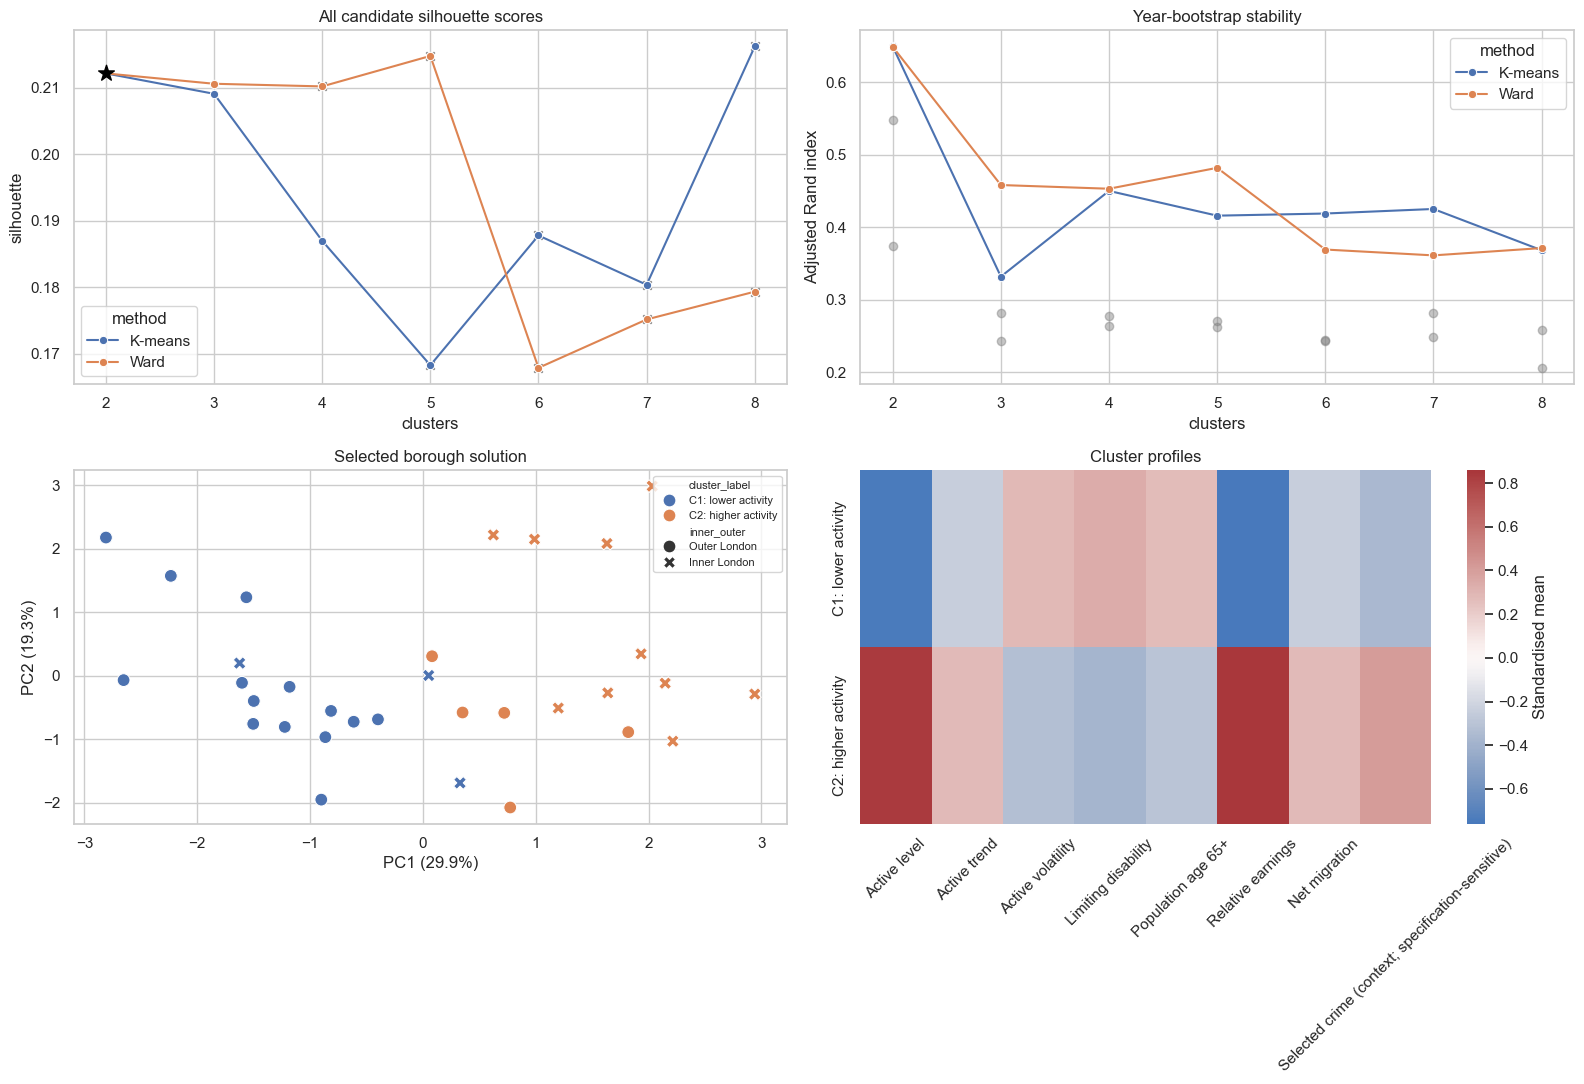

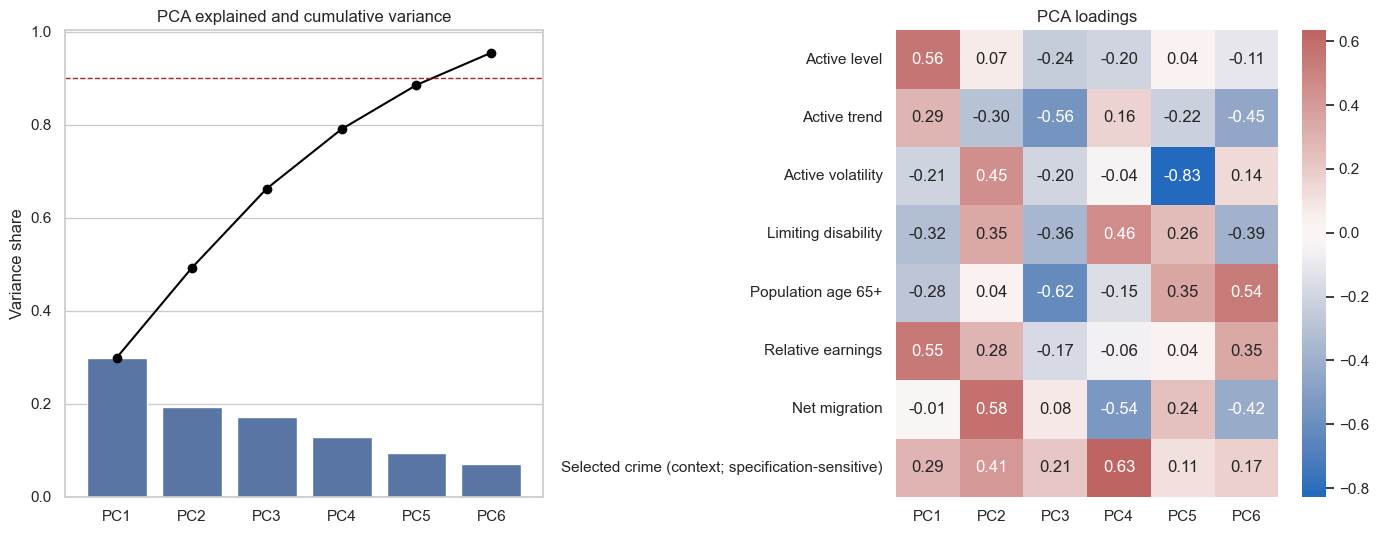

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.lineplot(data=cluster_candidates, x='clusters', y='silhouette', hue='method', marker='o', ax=axes[0, 0])
rejected = cluster_candidates.loc[~cluster_candidates['eligible']]
axes[0, 0].scatter(rejected['clusters'], rejected['silhouette'], marker='x', color='grey', label='Rejected: min n < 4')
axes[0, 0].scatter([selected_k], [winner['silhouette']], s=140, marker='*', color='black', zorder=5)
axes[0, 0].set_title('All candidate silhouette scores')

sns.lineplot(data=cluster_candidates, x='clusters', y='stability_median_ari', hue='method', marker='o',
             ax=axes[0, 1])
axes[0, 1].plot(cluster_candidates['clusters'], cluster_candidates['stability_p10_ari'],
                'o', color='grey', alpha=.45, label='10th-percentile ARI')
axes[0, 1].set(title='Year-bootstrap stability', ylabel='Adjusted Rand index')

sns.scatterplot(data=pca_coordinates, x='PC1', y='PC2', hue='cluster_label', style='inner_outer',
                s=85, ax=axes[1, 0])
axes[1, 0].set(
    title='Selected borough solution',
    xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
    ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
)
axes[1, 0].legend(fontsize=8, loc='best')

heat = profile.groupby('cluster_label')[cluster_features].mean()
heat = (heat - profile[cluster_features].mean()) / profile[cluster_features].std(ddof=0)
heat.columns = [cluster_feature_labels[x] for x in heat.columns]
sns.heatmap(heat, cmap='vlag', center=0, ax=axes[1, 1], cbar_kws={'label': 'Standardised mean'})
axes[1, 1].set_title('Cluster profiles')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('')
axes[1, 1].tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(data=pca_explained, x='component', y='explained_variance', color='#4c72b0', ax=axes[0])
axes[0].plot(pca_explained['component'], pca_explained['cumulative_variance'], marker='o', color='black')
axes[0].axhline(.90, color='firebrick', linestyle='--', linewidth=1)
axes[0].set(title='PCA explained and cumulative variance', ylabel='Variance share', xlabel='')
sns.heatmap(pca_loadings, cmap='vlag', center=0, annot=True, fmt='.2f', ax=axes[1])
axes[1].set(title='PCA loadings', xlabel='', ylabel='')
fig.tight_layout()
plt.show()

## 3. Inspect membership geographically

The map tests whether the selected solution is merely reproducing Inner/Outer London. Numbers link each polygon to the membership table without crowding the map with full borough names.

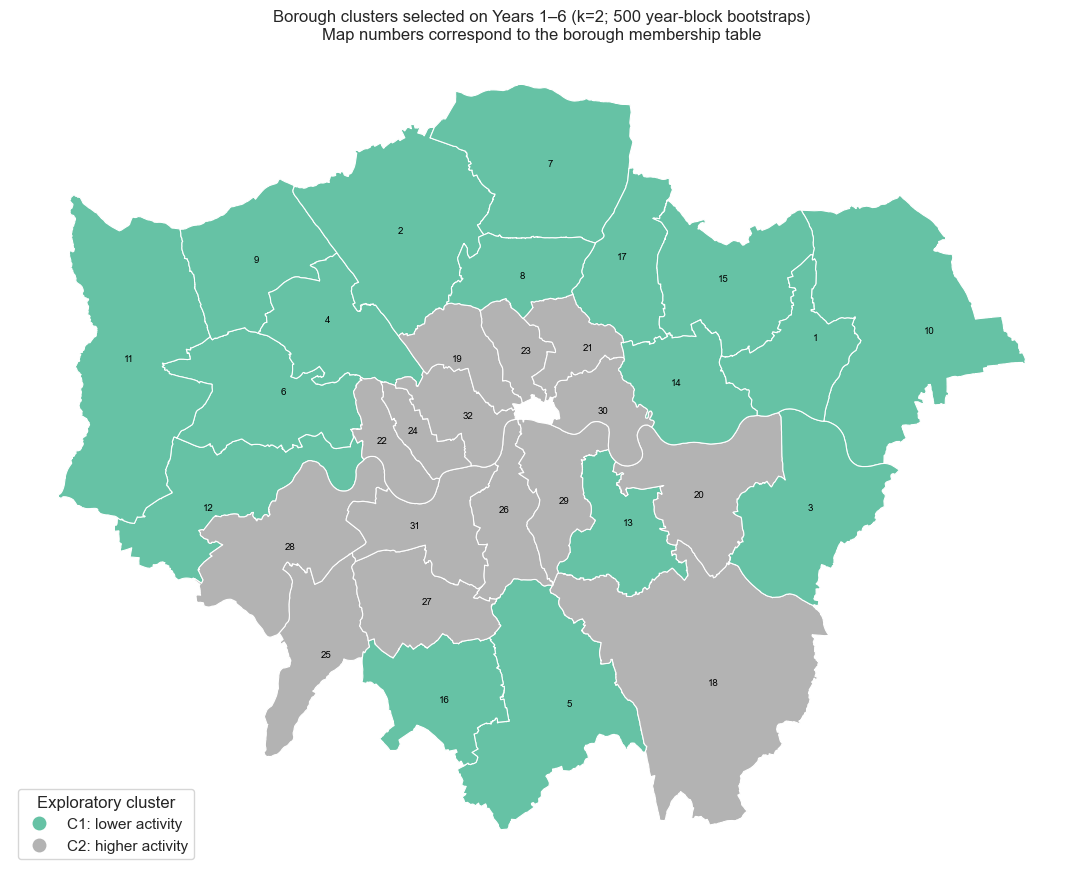

,map_id,geography_code,geography_name,inner_outer,cluster_id,cluster_label
0,1,E09000002,Barking and Dagenham,Outer London,1,C1: lower activity
1,2,E09000003,Barnet,Outer London,1,C1: lower activity
2,3,E09000004,Bexley,Outer London,1,C1: lower activity
3,4,E09000005,Brent,Outer London,1,C1: lower activity
4,5,E09000008,Croydon,Outer London,1,C1: lower activity
5,6,E09000009,Ealing,Outer London,1,C1: lower activity
6,7,E09000010,Enfield,Outer London,1,C1: lower activity
7,8,E09000014,Haringey,Inner London,1,C1: lower activity
8,9,E09000015,Harrow,Outer London,1,C1: lower activity
9,10,E09000016,Havering,Outer London,1,C1: lower activity


In [4]:
cluster_map_boundaries = borough_boundaries.loc[
    borough_boundaries['gss_code'].isin(borough_cluster_membership['geography_code'])
].copy()
assert len(cluster_map_boundaries) == 32
cluster_membership_map = cluster_map_boundaries.merge(
    borough_cluster_membership,
    left_on='gss_code', right_on='geography_code', how='left', validate='one_to_one'
)
assert cluster_membership_map['cluster_id'].notna().all(), 'Every borough boundary must receive one cluster.'

fig, ax = plt.subplots(figsize=(11, 11))
cluster_membership_map.plot(
    column='cluster_label', categorical=True, legend=True, cmap='Set2',
    edgecolor='white', linewidth=0.8, ax=ax,
    legend_kwds={'title': 'Exploratory cluster', 'loc': 'lower left'},
)
for _, row in cluster_membership_map.iterrows():
    point = row.geometry.representative_point()
    ax.text(point.x, point.y, str(int(row['map_id'])), ha='center', va='center', fontsize=7, color='black')
ax.set_axis_off()
ax.set_title(
    f'Borough clusters selected on Years 1–6 (k={selected_k}; '
    f'{CLUSTER_BOOTSTRAP_REPEATS} year-block bootstraps)\n'
    'Map numbers correspond to the borough membership table'
)
fig.tight_layout()
plt.show()

display(borough_cluster_membership)

## 4. Re-cluster four independent two-year windows

Each window—Years 1–2, 3–4, 5–6 and 7–8—chooses its own method and cluster count from 2–8. Because cluster numbers can differ, membership is compared using activity-ordered relative rank and Adjusted Rand Index rather than assuming label `C1` means the same thing everywhere.

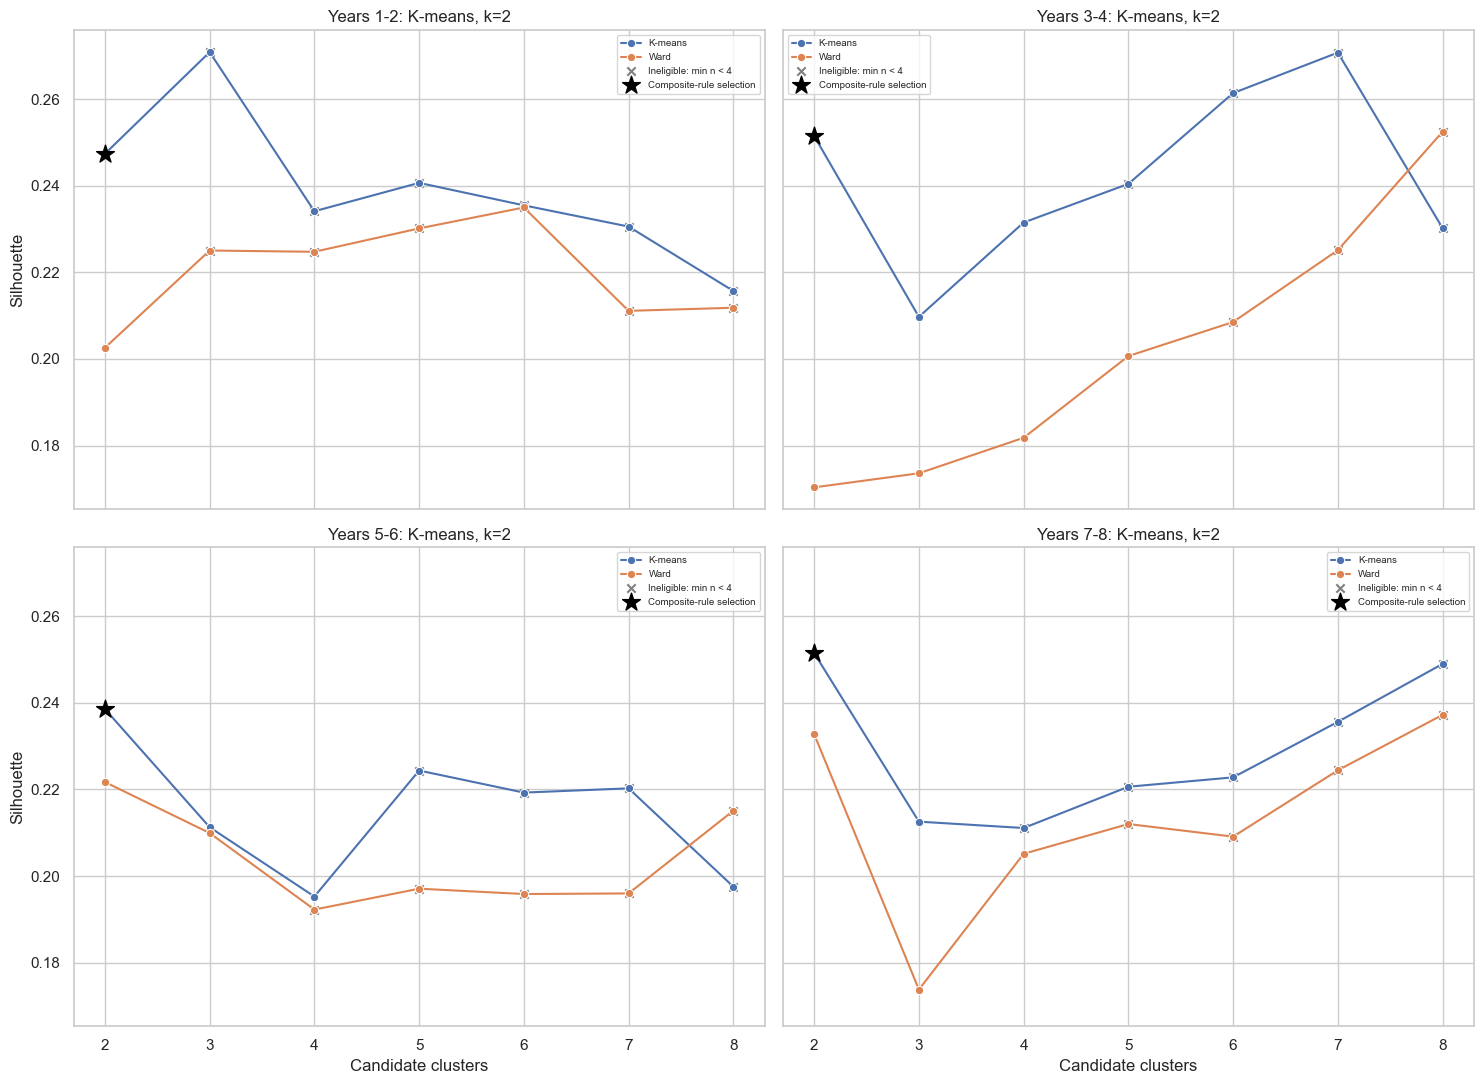

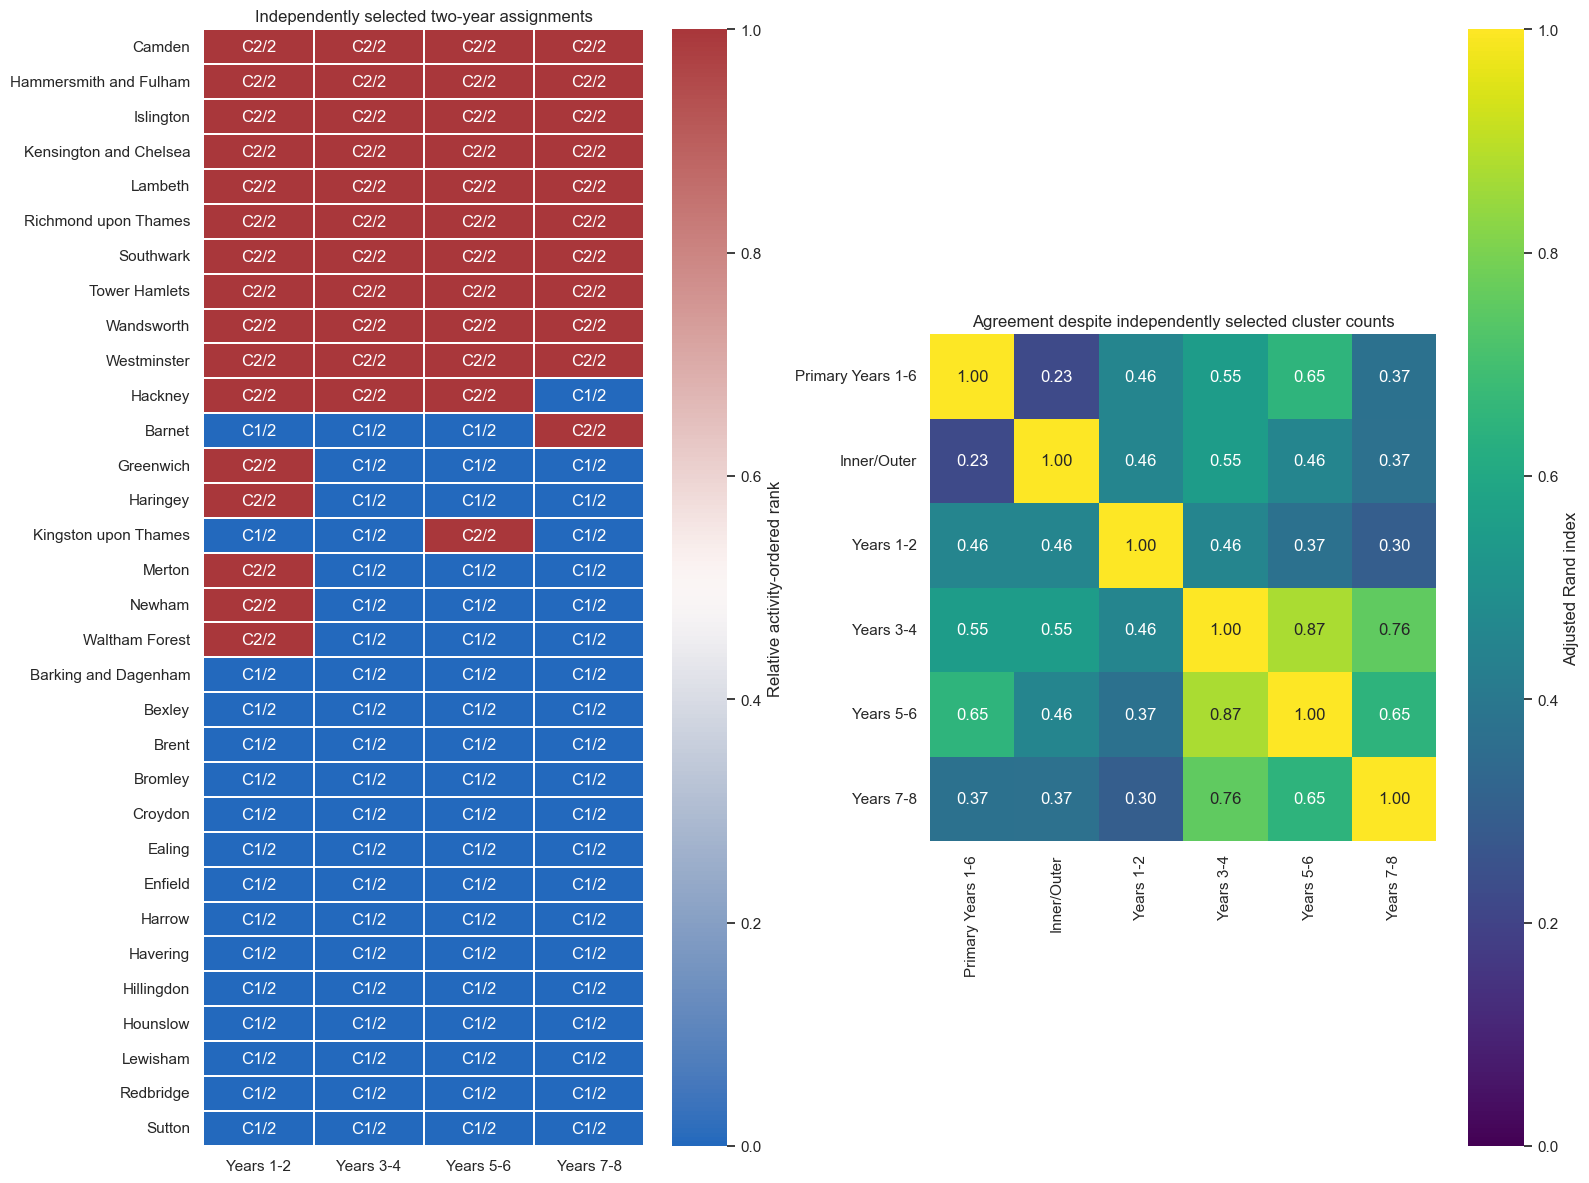

,window,method,clusters,silhouette,smallest_cluster,feature_omission_median_ari,feature_omission_p10_ari
0,Years 1-2,K-means,2,0.247,16,0.758,0.478
1,Years 3-4,K-means,2,0.251,11,0.758,0.647
2,Years 5-6,K-means,2,0.239,12,0.757,0.608
3,Years 7-8,K-means,2,0.251,11,0.874,0.713


,scope,window_start,method,clusters,feature_count,dynamic_feature_design,silhouette,smallest_cluster,stability_measure,stability_median_ari,stability_p10_ari,ari_with_inner_outer,ari_with_primary_years_1_6,ari_with_previous_window
0,Primary Years 1-6,0,K-means,2,8,Six-year Active trend and volatility,0.212,15,500 year-block bootstraps,0.650,0.548,0.226,1.000,NaN
1,Years 1-2,1,K-means,2,7,Two-year Active change,0.247,16,Leave-one-feature-out ARI,0.758,0.478,0.456,0.455,NaN
2,Years 3-4,3,K-means,2,7,Two-year Active change,0.251,11,Leave-one-feature-out ARI,0.758,0.647,0.548,0.549,0.457
3,Years 5-6,5,K-means,2,7,Two-year Active change,0.239,12,Leave-one-feature-out ARI,0.757,0.608,0.456,0.650,0.875
4,Years 7-8,7,K-means,2,7,Two-year Active change,0.251,11,Leave-one-feature-out ARI,0.874,0.713,0.371,0.372,0.648


,group,geography_name,inner_outer,assignment_pattern,mean_relative_cluster_rank,relative_cluster_rank_sd,large_rank_shifts
0,Consistently higher relative rank,Camden,Inner London,C2/2 -> C2/2 -> C2/2 -> C2/2,1.0,0.0,0
1,Consistently higher relative rank,Hammersmith and Fulham,Inner London,C2/2 -> C2/2 -> C2/2 -> C2/2,1.0,0.0,0
2,Consistently higher relative rank,Islington,Inner London,C2/2 -> C2/2 -> C2/2 -> C2/2,1.0,0.0,0
3,Consistently higher relative rank,Kensington and Chelsea,Inner London,C2/2 -> C2/2 -> C2/2 -> C2/2,1.0,0.0,0
4,Consistently higher relative rank,Lambeth,Inner London,C2/2 -> C2/2 -> C2/2 -> C2/2,1.0,0.0,0
5,Consistently higher relative rank,Richmond upon Thames,Outer London,C2/2 -> C2/2 -> C2/2 -> C2/2,1.0,0.0,0
26,Consistently lower relative rank,Havering,Outer London,C1/2 -> C1/2 -> C1/2 -> C1/2,0.0,0.0,0
27,Consistently lower relative rank,Hillingdon,Outer London,C1/2 -> C1/2 -> C1/2 -> C1/2,0.0,0.0,0
28,Consistently lower relative rank,Hounslow,Outer London,C1/2 -> C1/2 -> C1/2 -> C1/2,0.0,0.0,0
29,Consistently lower relative rank,Lewisham,Inner London,C1/2 -> C1/2 -> C1/2 -> C1/2,0.0,0.0,0


In [5]:
TWO_YEAR_WINDOWS = [(1, 2), (3, 4), (5, 6), (7, 8)]
TWO_YEAR_K_VALUES = range(2, 9)
TWO_YEAR_METHODS = ['K-means', 'Ward']
TWO_YEAR_MIN_CLUSTER_SIZE = 4
TWO_YEAR_KMEANS_N_INIT = 100
two_year_features = [
    'active_level', 'active_change_pp', 'limiting_disability',
    'population_age_65_plus', 'relative_earnings', 'net_migration', 'selected_crime',
]


def build_two_year_profile(frame, start_year, end_year):
    window = frame.loc[frame['year'].between(start_year, end_year)].copy()
    assert window['year'].nunique() == 2
    means = window.groupby(
        ['geography_code', 'geography_name', 'inner_outer'], as_index=False
    ).agg(
        active_level=('active_rate', 'mean'),
        limiting_disability=('limiting_disability_rate', 'mean'),
        population_age_65_plus=('population_age_65_plus_rate', 'mean'),
        relative_earnings=('earnings_relative_to_london', 'mean'),
        net_migration=('net_migration_per_1000', 'mean'),
        selected_crime=('selected_recorded_crime_rate_per_1000', 'mean'),
    )
    endpoints = window.pivot(index='geography_code', columns='year', values='active_rate')
    change = ((endpoints[end_year] - endpoints[start_year]) * 100).rename('active_change_pp')
    result = means.merge(change, on='geography_code', validate='one_to_one')
    assert len(result) == 32 and result[two_year_features].notna().all().all()
    return result


def fit_two_year_labels(method, clusters, values, seed=RANDOM_STATE):
    if method == 'K-means':
        return KMeans(
            n_clusters=clusters, n_init=TWO_YEAR_KMEANS_N_INIT, random_state=seed
        ).fit_predict(values)
    return AgglomerativeClustering(n_clusters=clusters, linkage='ward').fit_predict(values)


def order_labels_by_activity(frame, raw_labels):
    order = (
        frame.assign(raw_cluster=raw_labels)
        .groupby('raw_cluster')['active_level'].mean().sort_values().index
    )
    mapping = {raw: rank for rank, raw in enumerate(order, start=1)}
    return pd.Series(raw_labels).map(mapping).to_numpy()


def activity_ordered_label(cluster_id, clusters):
    if cluster_id == 1:
        descriptor = 'lower activity'
    elif cluster_id == clusters:
        descriptor = 'higher activity'
    else:
        descriptor = 'intermediate activity'
    return f'C{cluster_id}/{clusters}: {descriptor}'


primary_by_code = profile.set_index('geography_code')['cluster_id']
two_year_candidate_rows, two_year_all_membership_parts = [], []
window_profiles, window_scores_lookup = {}, {}

for start_year, end_year in TWO_YEAR_WINDOWS:
    window_name = f'Years {start_year}-{end_year}'
    window_profile = build_two_year_profile(borough_annual, start_year, end_year)
    scaled = StandardScaler().fit_transform(window_profile[two_year_features])
    window_pca = PCA(n_components=.90, random_state=RANDOM_STATE).fit(scaled)
    scores = window_pca.transform(scaled)
    window_profiles[window_name] = window_profile
    window_scores_lookup[window_name] = scores

    for method in TWO_YEAR_METHODS:
        for clusters in TWO_YEAR_K_VALUES:
            raw_labels = fit_two_year_labels(method, clusters, scores)
            ordered_labels = order_labels_by_activity(window_profile, raw_labels)
            counts = pd.Series(ordered_labels).value_counts()
            omission_ari = []
            for omitted in two_year_features:
                retained = [feature for feature in two_year_features if feature != omitted]
                retained_scaled = StandardScaler().fit_transform(window_profile[retained])
                retained_scores = PCA(
                    n_components=.90, random_state=RANDOM_STATE
                ).fit_transform(retained_scaled)
                omitted_labels = fit_two_year_labels(method, clusters, retained_scores)
                omission_ari.append(adjusted_rand_score(raw_labels, omitted_labels))

            candidate_id = f'{window_name}_{method}_k{clusters}'
            two_year_candidate_rows.append({
                'window': window_name, 'window_start': start_year, 'window_end': end_year,
                'candidate_id': candidate_id, 'method': method, 'clusters': clusters,
                'kmeans_n_init': TWO_YEAR_KMEANS_N_INIT if method == 'K-means' else np.nan,
                'pca_components_retained': window_pca.n_components_,
                'pca_variance_retained': window_pca.explained_variance_ratio_.sum(),
                'silhouette': silhouette_score(scores, raw_labels),
                'calinski_harabasz': calinski_harabasz_score(scores, raw_labels),
                'davies_bouldin': davies_bouldin_score(scores, raw_labels),
                'feature_omission_median_ari': float(np.median(omission_ari)),
                'feature_omission_p10_ari': float(np.quantile(omission_ari, .10)),
                'smallest_cluster': int(counts.min()),
                'largest_cluster': int(counts.max()),
            })
            membership = window_profile[[
                'geography_code', 'geography_name', 'inner_outer', *two_year_features
            ]].copy()
            membership.insert(0, 'candidate_id', candidate_id)
            membership.insert(0, 'window', window_name)
            membership['method'] = method
            membership['clusters'] = clusters
            membership['cluster_id'] = ordered_labels
            membership['cluster_label'] = [
                activity_ordered_label(int(value), clusters) for value in ordered_labels
            ]
            membership['relative_cluster_rank'] = (ordered_labels - 1) / (clusters - 1)
            two_year_all_membership_parts.append(membership)

two_year_cluster_candidates = pd.DataFrame(two_year_candidate_rows)
two_year_cluster_candidates['eligible'] = two_year_cluster_candidates['smallest_cluster'].ge(
    TWO_YEAR_MIN_CLUSTER_SIZE
)
rank_directions = {
    'silhouette': 1, 'calinski_harabasz': 1, 'davies_bouldin': -1,
    'feature_omission_median_ari': 1, 'feature_omission_p10_ari': 1,
}
for window_name, group in two_year_cluster_candidates.groupby('window'):
    eligible_index = group.index[group['eligible']]
    assert len(eligible_index), f'No eligible two-year cluster candidate for {window_name}'
    for metric, direction in rank_directions.items():
        good = direction * two_year_cluster_candidates.loc[eligible_index, metric]
        two_year_cluster_candidates.loc[eligible_index, f'rank_{metric}'] = good.rank(pct=True)
rank_columns = [column for column in two_year_cluster_candidates if column.startswith('rank_')]
two_year_cluster_candidates['selection_score'] = two_year_cluster_candidates[rank_columns].mean(axis=1)

selected_rows = []
for window_name, group in two_year_cluster_candidates.loc[
    two_year_cluster_candidates['eligible']
].groupby('window'):
    selected_rows.append(group.sort_values(
        ['selection_score', 'feature_omission_median_ari', 'silhouette'], ascending=False
    ).iloc[0])
two_year_selected_solutions = pd.DataFrame(selected_rows).sort_values('window_start').reset_index(drop=True)
selected_candidate_ids = set(two_year_selected_solutions['candidate_id'])
two_year_cluster_candidates['selected'] = two_year_cluster_candidates['candidate_id'].isin(
    selected_candidate_ids
)

two_year_all_membership = pd.concat(two_year_all_membership_parts, ignore_index=True)
two_year_all_membership['selected'] = two_year_all_membership['candidate_id'].isin(
    selected_candidate_ids
)
two_year_cluster_membership = two_year_all_membership.loc[
    two_year_all_membership['selected']
].copy()
window_order = {f'Years {start}-{end}': start for start, end in TWO_YEAR_WINDOWS}
two_year_cluster_membership['window_start'] = two_year_cluster_membership['window'].map(window_order)
two_year_cluster_membership['primary_cluster_id'] = two_year_cluster_membership[
    'geography_code'
].map(primary_by_code)
two_year_cluster_membership['primary_relative_rank'] = (
    two_year_cluster_membership['primary_cluster_id'] - 1
) / max(selected_k - 1, 1)
two_year_cluster_membership['relative_rank_difference_from_primary'] = (
    two_year_cluster_membership['relative_cluster_rank']
    - two_year_cluster_membership['primary_relative_rank']
)
two_year_cluster_membership = two_year_cluster_membership.sort_values(
    ['window_start', 'relative_cluster_rank', 'geography_name']
).reset_index(drop=True)

window_labels, validation_rows = {}, []
previous_labels = None
for _, selected in two_year_selected_solutions.iterrows():
    window_name = selected['window']
    local = two_year_cluster_membership.loc[
        two_year_cluster_membership['window'].eq(window_name)
    ].sort_values('geography_code')
    labels = local.set_index('geography_code')['cluster_id']
    window_labels[window_name] = labels
    inner_codes = local['inner_outer'].astype('category').cat.codes
    primary_labels = local['primary_cluster_id'].to_numpy()
    validation_rows.append({
        'scope': window_name, 'window_start': selected['window_start'],
        'method': selected['method'], 'clusters': int(selected['clusters']),
        'feature_count': len(two_year_features), 'dynamic_feature_design': 'Two-year Active change',
        'silhouette': selected['silhouette'],
        'smallest_cluster': int(selected['smallest_cluster']),
        'stability_measure': 'Leave-one-feature-out ARI',
        'stability_median_ari': selected['feature_omission_median_ari'],
        'stability_p10_ari': selected['feature_omission_p10_ari'],
        'ari_with_inner_outer': adjusted_rand_score(inner_codes, labels.to_numpy()),
        'ari_with_primary_years_1_6': adjusted_rand_score(primary_labels, labels.to_numpy()),
        'ari_with_previous_window': (
            adjusted_rand_score(previous_labels.reindex(labels.index), labels)
            if previous_labels is not None else np.nan
        ),
    })
    previous_labels = labels

primary_validation_row = {
    'scope': 'Primary Years 1-6', 'window_start': 0, 'method': selected_method,
    'clusters': selected_k, 'feature_count': len(cluster_features),
    'dynamic_feature_design': 'Six-year Active trend and volatility',
    'silhouette': winner['silhouette'], 'smallest_cluster': int(winner['smallest_cluster']),
    'stability_measure': f'{CLUSTER_BOOTSTRAP_REPEATS} year-block bootstraps',
    'stability_median_ari': winner['stability_median_ari'],
    'stability_p10_ari': winner['stability_p10_ari'],
    'ari_with_inner_outer': inner_outer_ari, 'ari_with_primary_years_1_6': 1.0,
    'ari_with_previous_window': np.nan,
}
two_year_cluster_validation = pd.concat([
    pd.DataFrame([primary_validation_row]), pd.DataFrame(validation_rows)
], ignore_index=True)

chronological = two_year_cluster_membership.sort_values(['geography_code', 'window_start']).copy()
chronological['previous_relative_rank'] = chronological.groupby(
    'geography_code'
)['relative_cluster_rank'].shift(1)
chronological['large_rank_shift_from_previous'] = (
    chronological['relative_cluster_rank'].sub(chronological['previous_relative_rank']).abs().ge(.5)
)
chronological.loc[chronological['window_start'].eq(1), 'large_rank_shift_from_previous'] = False
two_year_cluster_membership = two_year_cluster_membership.merge(
    chronological[[
        'window', 'geography_code', 'previous_relative_rank', 'large_rank_shift_from_previous'
    ]], on=['window', 'geography_code'], validate='one_to_one'
)

patterns = chronological.groupby('geography_code').apply(
    lambda x: ' -> '.join(
        f"C{int(row.cluster_id)}/{int(row.clusters)}" for row in x.sort_values('window_start').itertuples()
    ), include_groups=False,
)
two_year_cluster_frequency = chronological.groupby(
    ['geography_code', 'geography_name', 'inner_outer'], as_index=False
).agg(
    top_cluster_windows=('relative_cluster_rank', lambda x: int(np.isclose(x, 1).sum())),
    bottom_cluster_windows=('relative_cluster_rank', lambda x: int(np.isclose(x, 0).sum())),
    mean_relative_cluster_rank=('relative_cluster_rank', 'mean'),
    relative_cluster_rank_sd=('relative_cluster_rank', lambda x: float(np.std(x, ddof=0))),
    large_rank_shifts=('large_rank_shift_from_previous', 'sum'),
    primary_cluster_id=('primary_cluster_id', 'first'),
)
two_year_cluster_frequency['assignment_pattern'] = two_year_cluster_frequency[
    'geography_code'
].map(patterns)
two_year_cluster_frequency = two_year_cluster_frequency.sort_values(
    ['mean_relative_cluster_rank', 'relative_cluster_rank_sd', 'geography_name'],
    ascending=[False, True, True],
).reset_index(drop=True)

comparison_labels = {
    'Primary Years 1-6': primary_by_code,
    'Inner/Outer': profile.set_index('geography_code')['inner_outer'].astype('category').cat.codes,
    **window_labels,
}
comparison_names = list(comparison_labels)
two_year_ari_matrix = pd.DataFrame(index=comparison_names, columns=comparison_names, dtype=float)
for row_name, row_labels in comparison_labels.items():
    for column_name, column_labels in comparison_labels.items():
        aligned = pd.concat([
            pd.Series(row_labels, name='row'), pd.Series(column_labels, name='column')
        ], axis=1).dropna()
        two_year_ari_matrix.loc[row_name, column_name] = adjusted_rand_score(
            aligned['row'], aligned['column']
        )

ordered_codes = two_year_cluster_frequency['geography_code'].tolist()
ordered_names = two_year_cluster_frequency.set_index('geography_code').loc[
    ordered_codes, 'geography_name'
]
same_cluster_counts = np.zeros((len(ordered_codes), len(ordered_codes)), dtype=float)
for labels in window_labels.values():
    vector = labels.reindex(ordered_codes).to_numpy()
    same_cluster_counts += vector[:, None] == vector[None, :]
two_year_coclustering_frequency = pd.DataFrame(
    same_cluster_counts / len(TWO_YEAR_WINDOWS), index=ordered_names, columns=ordered_names
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True, sharey=True)
for ax, (window_name, candidates) in zip(axes.flat, two_year_cluster_candidates.groupby('window')):
    sns.lineplot(
        data=candidates, x='clusters', y='silhouette', hue='method', marker='o', ax=ax
    )
    rejected = candidates.loc[~candidates['eligible']]
    ax.scatter(
        rejected['clusters'], rejected['silhouette'], color='grey', marker='x',
        label=f'Ineligible: min n < {TWO_YEAR_MIN_CLUSTER_SIZE}',
    )
    selected = candidates.loc[candidates['selected']].iloc[0]
    ax.scatter(
        [selected['clusters']], [selected['silhouette']], color='black', marker='*', s=180,
        zorder=5, label='Composite-rule selection',
    )
    ax.set_title(f"{window_name}: {selected['method']}, k={int(selected['clusters'])}")
    ax.set_xlabel('Candidate clusters')
    ax.set_ylabel('Silhouette')
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

assignment_rank = two_year_cluster_membership.pivot(
    index='geography_name', columns='window', values='relative_cluster_rank'
).reindex(index=ordered_names, columns=[f'Years {a}-{b}' for a, b in TWO_YEAR_WINDOWS])
assignment_annotation = two_year_cluster_membership.assign(
    notation=lambda x: 'C' + x['cluster_id'].astype(int).astype(str) + '/' + x['clusters'].astype(int).astype(str)
).pivot(index='geography_name', columns='window', values='notation').reindex(
    index=ordered_names, columns=assignment_rank.columns
)
fig, axes = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1.15]})
sns.heatmap(
    assignment_rank, cmap='vlag', vmin=0, vmax=1, center=.5,
    annot=assignment_annotation, fmt='', cbar_kws={'label': 'Relative activity-ordered rank'},
    linewidths=.25, ax=axes[0],
)
axes[0].set(title='Independently selected two-year assignments', xlabel='', ylabel='')
sns.heatmap(
    two_year_ari_matrix, cmap='viridis', vmin=0, vmax=1, annot=True, fmt='.2f',
    square=True, cbar_kws={'label': 'Adjusted Rand index'}, ax=axes[1],
)
axes[1].set(title='Agreement despite independently selected cluster counts', xlabel='', ylabel='')
fig.tight_layout()
plt.show()

display(two_year_selected_solutions[[
    'window', 'method', 'clusters', 'silhouette', 'smallest_cluster',
    'feature_omission_median_ari', 'feature_omission_p10_ari',
]].round(3))
display(two_year_cluster_validation.round(3))
display(pd.concat([
    two_year_cluster_frequency.head(6).assign(group='Consistently higher relative rank'),
    two_year_cluster_frequency.tail(6).assign(group='Consistently lower relative rank'),
])[['group', 'geography_name', 'inner_outer', 'assignment_pattern',
    'mean_relative_cluster_rank', 'relative_cluster_rank_sd', 'large_rank_shifts']])

# Final findings

## Primary Years 1–6 solution

The audited selection chooses **K-means with two clusters**. This is not because the search was restricted to two: K-means and Ward were both compared for 2–8 clusters. Solutions with fewer than four boroughs in any cluster were excluded, and the remaining candidates were ranked jointly on separation and stability. The selected solution has 17 lower-profile and 15 higher-profile boroughs, silhouette 0.212, and a median year-block bootstrap ARI of 0.650 (10th percentile 0.548 across 500 repeats). It is reproducible enough for broad typology, but the modest silhouette means it should not be described as two sharply separated kinds of borough.

The clustering is **not a relabelled Inner/Outer London map**. Its ARI with the official split is only 0.226: Haringey, Lewisham and Newham join the lower-profile group, while the higher-profile group contains Outer boroughs including Bromley, Greenwich, Kingston upon Thames, Merton and Richmond upon Thames. Validation against a fresh Years 7–8 profile is also modest (ARI 0.295), showing that the broad structure persists only partially.

PCA retains six components to reach 95.5% explained variance, so the eight indicators do not collapse to a single hidden dimension. PC1 mainly contrasts higher Active levels and relative earnings with limiting disability and older population structure. Feature omission confirms where membership depends: removing Active level reduces ARI to 0.457 and removing relative earnings to 0.649, whereas omitting Active trend, age 65+ or the specification-sensitive crime feature leaves membership unchanged. The result is therefore primarily a level-and-affluence typology, not strong evidence of distinct change trajectories.

## Independent two-year windows

All four windows independently select K-means with two clusters, even though each was allowed to choose 2–8. Their silhouettes (0.239–0.251) are slightly higher than the primary solution and leave-one-feature-out median ARIs range from 0.757 to 0.874. This repeated preference is evidence for a broad low/high continuum split, but not for immutable membership. Agreement between adjacent windows is only ARI 0.457 from Years 1–2 to 3–4, rises to 0.875 for 3–4 versus 5–6, then falls to 0.648 for 5–6 versus 7–8.

The two-year groups resemble Inner/Outer London more than the primary profile does, but still only partially (ARI 0.371–0.548). Six boroughs stay in the higher relative group in all four windows: Camden, Hammersmith and Fulham, Islington, Kensington and Chelsea, Lambeth, and Richmond upon Thames. Six stay in the lower group throughout: Havering, Hillingdon, Hounslow, Lewisham, Redbridge, and Sutton. Richmond and Lewisham are especially useful counterexamples to the claim that clustering simply rediscovers Inner/Outer London.

## Interpretation

The honest conclusion is neither ‘the clusters are accidental’ nor ‘London has two fixed natural types’. The evidence supports a recurring broad socioeconomic/activity gradient with a stable core and a movable middle. Two clusters win because they are the most stable coarse summary under a 32-borough sample and minimum-size rule; additional clusters fragment into small or unstable groups. For reporting, use the primary map as a compact typology, the two-year heatmap to show movement, and retain Inner/Outer London as a separate administrative comparison rather than treating either classification as ground truth.